In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('predict_results_from_gpt.csv')
df_original = pd.read_csv('../polygraphpy/data/polarizability_data.csv')

In [3]:
df_modified = df.iloc[1:]
df_modified.sort_values(by='error')

,smiles_A,y,pred,error
97,CCCCCCCCCCCCCCCCCCOC(=O)/C=C/C1=CC(=C(C=C1)O)O,0.283668,0.285700,0.007163
38,CCOC(=O)C(=C)CC1=C(C=CS1)C,0.114613,0.113696,0.008007
43,CCOC(=O)/C=C/C1=C(C=CC=C1Cl)C(F)(F)F,0.128940,0.126688,0.017464
228,CC(=O)C1=C(C=CC2=C1SC3=CC=CC=C23)O,0.710602,0.726799,0.022793
67,COC(=O)/C=C/C1=CC=C(C=C1)O[C@H1][C@@H1]([C@H1]...,0.197708,0.193157,0.023018
...,...,...,...,...
21,CC1C(C)(CCC1O)C(=O)C=C,0.065903,0.414118,5.283798
5,C=CC(=O)ON1C(=O)CCC1=O,0.014327,0.090627,5.325738
3,C=CC(=O)OCC(CCl)(C(F)(F)F)C(F)(F)F,0.008596,0.078739,8.160023
14,CCNC(=O)C=C,0.040115,0.659799,15.447856


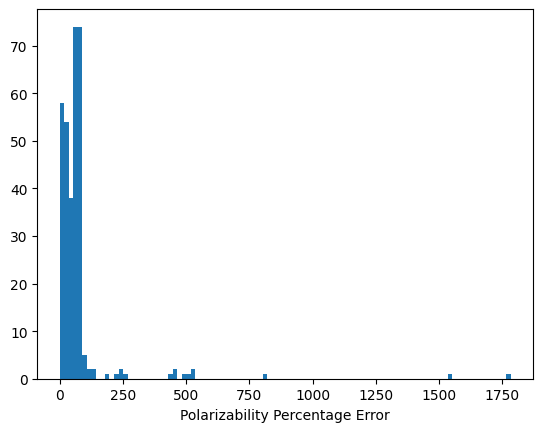

In [4]:
plt.hist(100*df_modified['error'], bins=100)
plt.xlabel('Polarizability Percentage Error')
plt.show()

100


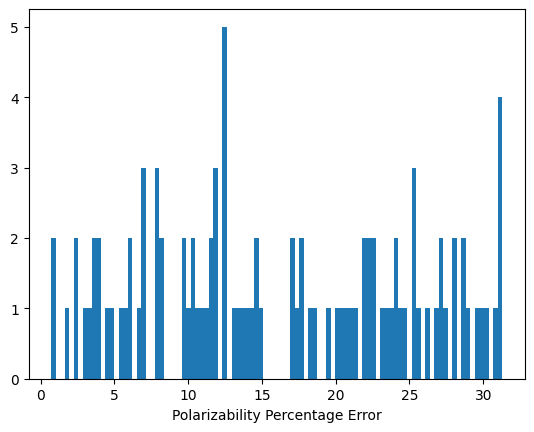

In [5]:
df_modified = df_modified.sort_values(by='error').head(100)
print(len(df_modified))

plt.hist(100*df_modified['error'], bins=100)
plt.xlabel('Polarizability Percentage Error')
plt.show()

In [6]:
100*df_modified['error'].describe()

count    10000.000000
mean        16.189760
std          8.993339
min          0.716305
25%          8.216460
50%         14.616992
75%         24.033761
max         31.274196
Name: error, dtype: float64

In [7]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error

df_error = pd.DataFrame({
            'mape': round(mean_absolute_percentage_error(df_modified.y.values, df_modified.pred.values) * 100, 5),
            'r2': round(r2_score(df_modified.y.values, df_modified.pred.values), 5),
            'mse': round(mean_squared_error(df_modified.y.values, df_modified.pred.values), 5)
        }, index=[0])
print(df_error)

       mape       r2      mse
0  16.18976  0.88149  0.00372


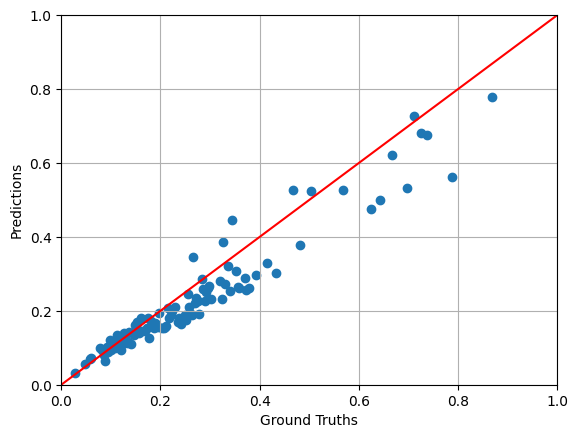

In [8]:
import numpy as np

p1 = [0, 1]
p2 = [0, 1]

coefficients = np.polyfit(p1, p2, 1)

polynomial = np.poly1d(coefficients)
x_axis = np.linspace(0, 1, 500)
y_axis = polynomial(x_axis)

fig = plt.figure()
plt.scatter(df_modified.y.values, df_modified.pred.values)
plt.plot(x_axis, y_axis, 'r')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(1)
plt.xlabel("Ground Truths")
plt.ylabel("Predictions")
plt.show()